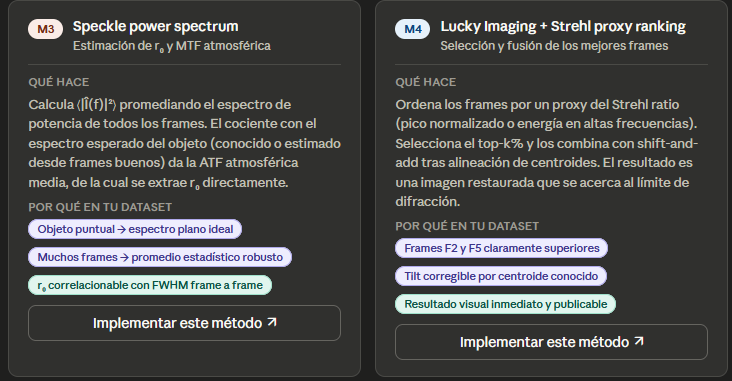

# M4 - Lucky Imaging + Strehl Proxy Ranking

La atmósfera introduce turbulencia que varía en el tiempo. En cualquier secuencia de frames, algunos instantes la turbulencia se "calma" momentáneamente y el frame sale más nítido. Por lo que en la universidad de Cambridge se les ocurrio el metodo Lucky Imaging, que en lugar de pelear con la atmósfera, se iban a basar más en estadistica.


En palabras simples **Lucky Imaging** es como hacer darwinismo astrofisico,  en vez de promediar todos los frames (que diluye los buenos con los malos), elige solo los **mejores** (siendo super estrictos al momento de elegir los mejores, botar el resto a la basura y apilar lo mejor puede hacer que el la resolución de un telescopío se multiplique por 4).

## Método Imagen afortunada
El método tiene 4 pasos concretos:

* Calcular el Strehl proxy de cada frame (energía en altas frecuencias)
* Rankear los frames de mejor a peor
* Seleccionar el top-k% (típicamente 10–30%, nosotros usaremos 20%)
* Shift-and-add — alinear por centroide y promediar

# 0. Previo a método, carga del dataset

El dataset es de: https://zenodo.org/records/7064324

Usamos solo una fracción de el dataset ya que no requeriamos de todo el dataset para nuestro proyecto, así que elegimos usar unas cuantas.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#Librerias
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage


In [3]:
# Ruta a los archivos fits
FITS_PATH = "/content/drive/MyDrive/2026-1/INF405- PROCESAMIENTO/Proyecto/Datasat - Nayely/continuum_200p_00000.fits"

with fits.open(FITS_PATH) as hdul:
  hdul.info()
  data = hdul[0].data.astype(np.float64)
  header = hdul[0].header
## Imprimo
print(f"Shape del cubo: {data.shape}  →  {data.shape[0]} frames de {data.shape[1]}×{data.shape[2]} px")
print(f"Rango de valores: [{data.min():.1f}, {data.max():.1f}]")

Filename: /content/drive/MyDrive/2026-1/INF405- PROCESAMIENTO/Proyecto/Datasat - Nayely/continuum_200p_00000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      25   (200, 200, 200)   int16   
Shape del cubo: (200, 200, 200)  →  200 frames de 200×200 px
Rango de valores: [-11232.0, 22960.0]


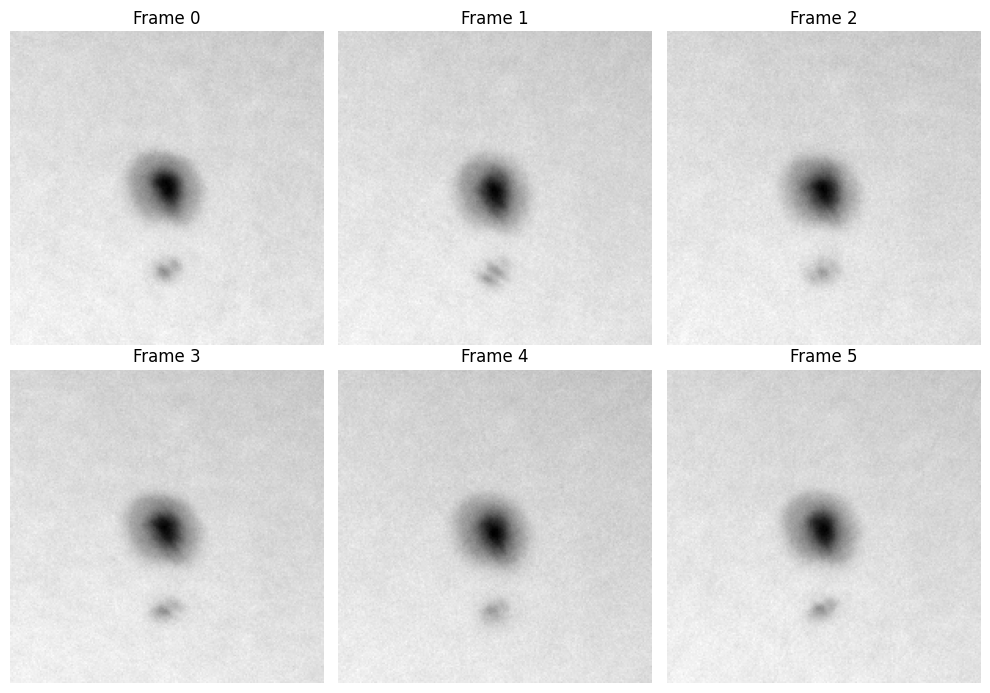

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(10,7))

for i, ax in enumerate(axes.flat):

    ax.imshow(data[i], cmap="gray")
    ax.set_title(f"Frame {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# 1. Normalización
Para entender esto, primero debemos que es el Ratio de Strehl.

Buscamos una forma de medir matematicamente la perfección de una imagen. Ahi es cuando aparece el

***Ratio de Strehl*** : es una puntuación matemática que va de 0 a 1, mientras más cerca del 1 significa que es más perfecta.

**def:** Proporción de intensidad de una imagen aberrada comparada con un sistema ideal sin difracción.


Así que escalamos cada frame independientemente a [0, 1] para que el Strehl proxy no dependa de la brillantez absoluta, sino solo de la nitidez relativa.

In [5]:
# normalizamos de un frame 2d a [0,1]
def normalizacion_frame(frame):
  mn, mx = frame.min(), frame.max()
  if mx==mn:
    return np.zeros_like(frame)
  return(frame -mn) /(mx -mn)

In [8]:
# normalizar todo
frames = np.array([normalizacion_frame(data[i]) for i in range(data.shape[0])])
# N = frames , H = alto ,W =largo
N,H,W = frames.shape
print(f"Cubo normalizado: {N} frames de {H} × {W} px")

Cubo normalizado: 200 frames de 200 × 200 px


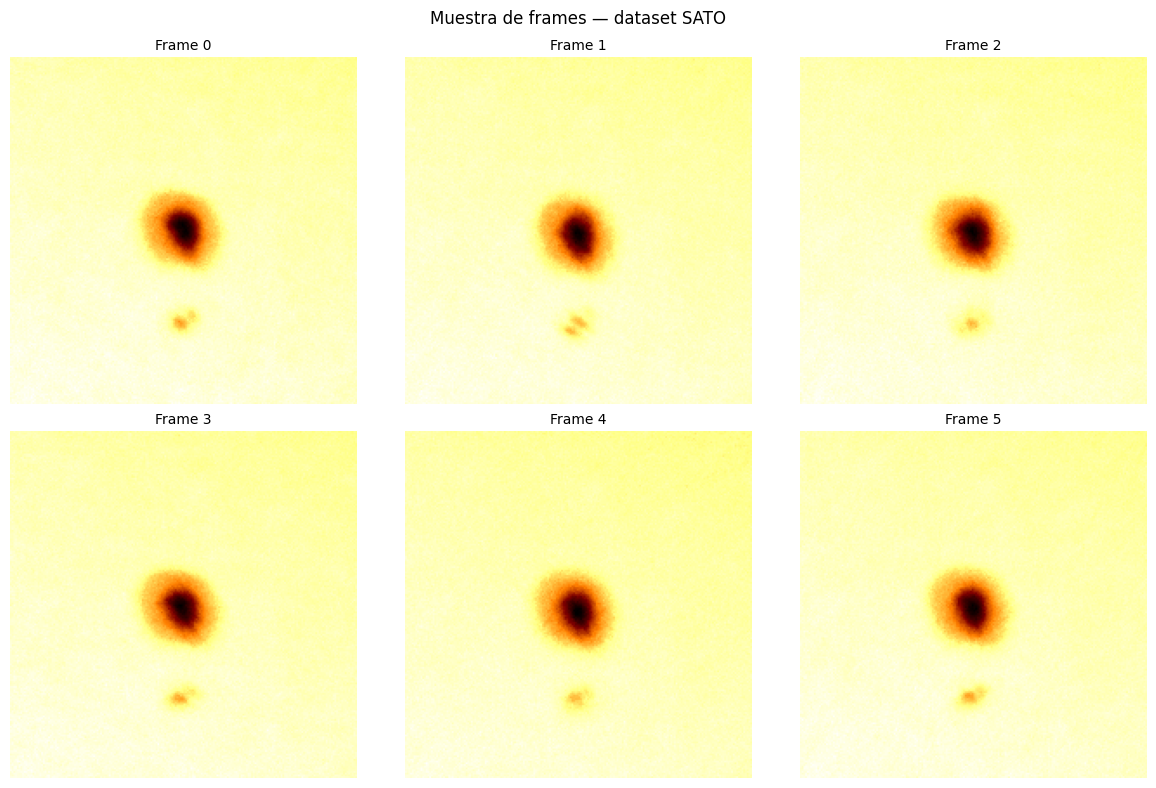

In [9]:
# Vista rápida de los primeros 6 frames
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(frames[i], cmap="afmhot", vmin=0, vmax=1)
    ax.set_title(f"Frame {i}", fontsize=10)
    ax.axis("off")
plt.suptitle("Muestra de frames — dataset SATO", fontsize=12)
plt.tight_layout()
plt.show()

#2 . Strehl Proxy
Para imágenes solares (fuente extendida), la energía en altas
frecuencias FFT no discrimina bien entre frames nítidos y borrosos.
En cambio, el gradiente RMS mide qué tan marcados son los bordes
locales (manchas solares, filamentos, borde del disco) — que sí cambian visiblemente entre un frame nítido y uno borroso.

* Un frame nítido tiene bordes pronunciados → gradiente alto.

* Un frame borroso tiene bordes difuminados → gradiente bajo.

 RMS significa Root Mean Square — raíz cuadrada del promedio de los cuadrados. Es simplemente una forma de promediar que no se cancela con positivos y negativos.

In [10]:
#Proxy de nitidez basado en gradiente RMS.
def strehl_proxy(frame, radius_fraction=0.25):
    gy = np.gradient(frame, axis=0) ## pendiente vertical (arriba-abajo)
    gx = np.gradient(frame, axis=1) # pendiente horizontal (izquierda-derecha)
    return float(np.sqrt(gx**2 + gy**2).mean()) #el promedio

In [11]:
# Calcular proxy para todos los frames
proxies = np.array([strehl_proxy(frames[i]) for i in range(N)])

print("Strehl proxies (primeros 10):", np.round(proxies[:10], 4))
print(f"Mejor frame:  #{np.argmax(proxies)}  (proxy={proxies.max():.4f})")
print(f"Peor frame:   #{np.argmin(proxies)}  (proxy={proxies.min():.4f})")
print(f"Media:        {proxies.mean():.4f}  ±  {proxies.std():.4f}")

Strehl proxies (primeros 10): [0.0164 0.0163 0.0167 0.0162 0.0166 0.0162 0.0161 0.0163 0.0164 0.0167]
Mejor frame:  #76  (proxy=0.0199)
Peor frame:   #180  (proxy=0.0154)
Media:        0.0163  ±  0.0005


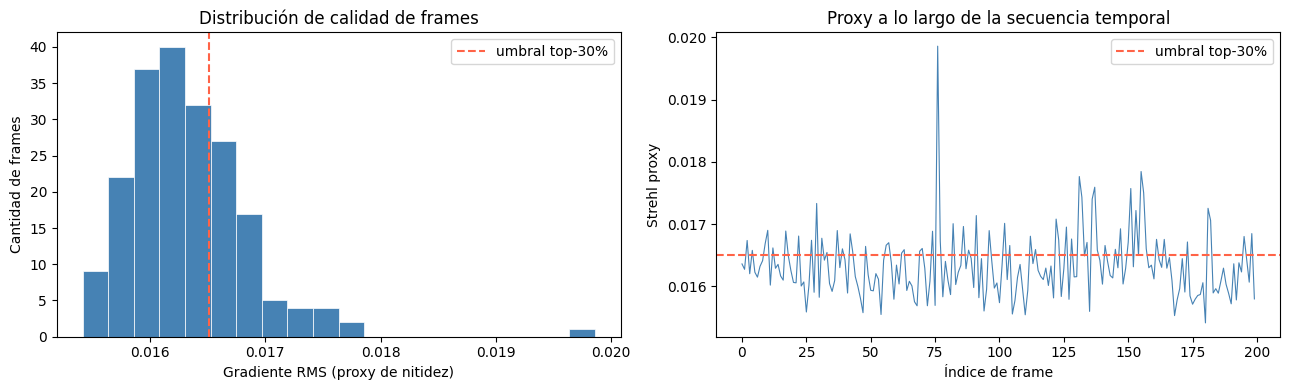

In [13]:
# Distribución de proxies
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(proxies, bins=20, color="steelblue", edgecolor="white", linewidth=0.5)
axes[0].set_xlabel("Gradiente RMS (proxy de nitidez)")
axes[0].set_ylabel("Cantidad de frames")
axes[0].set_title("Distribución de calidad de frames")
axes[0].axvline(np.percentile(proxies, 70), color="tomato", linestyle="--",
                label="umbral top-30%")
axes[0].legend()

axes[1].plot(proxies, color="steelblue", linewidth=0.8)
axes[1].set_xlabel("Índice de frame")
axes[1].set_ylabel("Strehl proxy")
axes[1].set_title("Proxy a lo largo de la secuencia temporal")
axes[1].axhline(np.percentile(proxies, 70), color="tomato", linestyle="--",
                label="umbral top-30%")
axes[1].legend()

plt.tight_layout()
plt.show()

# 3. Selección top-k%
Elegimos los frames con mayor proxy. El valor de k es el parámetro clave del método: un k muy pequeño da mayor nitidez pero más ruido (pocos frames promediados); un k grande reduce ruido pero incluye frames mediocres.

In [14]:
# Selecciona el top-k% de frames según su Strehl proxy.
def select_top_k(frmaes, proxies, k_percent=20):
    n_keep    = max(1, int(len(proxies) * k_percent / 100))
    threshold = np.percentile(proxies, 100 - k_percent)
    indices   = np.argsort(proxies)[::-1][:n_keep]   # ordenados de mejor a peor
    return frames[indices], indices, threshold

In [16]:
K_PERCENT = 20   # ← ajustar este valor para experimentar

selected_frames, selected_indices, threshold = select_top_k(frames, proxies, K_PERCENT)
print(f"Top-{K_PERCENT}%: {len(selected_indices)} frames seleccionados de {N}")
print(f"Umbral de proxy: {threshold:.4f}")
#print(f"Índices seleccionados: {sorted(selected_indices.tolist())}")

Top-20%: 40 frames seleccionados de 200
Umbral de proxy: 0.0167


# 4. Shift-and-Add: Alineación por centroide

Antes de promediar, alineamos los frames. La turbulencia atmosférica introduce tilt (desplazamiento rígido de toda la imagen). Estimamos el desplazamiento de cada frame respecto al de referencia usando el centroide de la imagen, y corregimos con una traslación sub-píxel.

El frame de referencia es el de mayor proxy (el más nítido).
Para imágenes solares, el centroide corresponde aproximadamente al centro del disco solar, que debería estar en la misma posición en todos los frames si no hubiera tilt atmosférico.

    Returns:
        (cy, cx): coordenadas del centroide en píxeles.

In [17]:
# calculamos el centroide (centro de masa) de la imagen.
def centroide(frame):
  total= frame.sum()+ 1e-10
  Y, X  = np.mgrid[:frame.shape[0], :frame.shape[1]]
  cy    = (Y * frame).sum() / total
  cx    = (X * frame).sum() / total
  return cy, cx

Alinea todos los frames al frame de referencia y los promedia.

El desplazamiento se calcula como la diferencia de centroides entre
cada frame y el de referencia. Se usa interpolación spline (ndimage.shift) para desplazamientos sub-píxel.

In [25]:
def shift_and_add(frames_to_stack, reference_idx=0):
  ref_frame  = frames_to_stack[reference_idx]
  ref_cy, ref_cx = centroide(ref_frame)
  aligned = []
  shifts  = []
  for frame in frames_to_stack:
      cy, cx = centroide(frame)
      dy     = ref_cy - cy
      dx     = ref_cx - cx
      shifts.append((dy, dx))
      aligned.append(ndimage.shift(frame, shift=(dy, dx), order=3))

  stacked = np.mean(aligned, axis=0)
  stacked = np.clip(stacked, 0, 1)
  return stacked, shifts

In [26]:
# El primer índice en selected_frames ya es el de mayor proxy (mejor frame)
lucky_image, shifts = shift_and_add(selected_frames, reference_idx=0)

shifts_arr = np.array(shifts)
print(f"Imagen lucky generada. Shape: {lucky_image.shape}")
print("Desplazamientos aplicados")
print(f"dy: [{shifts_arr[:,0].min():.2f}, {shifts_arr[:,0].max():.2f}] px")
print(f"dx: [{shifts_arr[:,1].min():.2f}, {shifts_arr[:,1].max():.2f}] px")

Imagen lucky generada. Shape: (200, 200)
Desplazamientos aplicados
dy: [0.00, 0.91] px
dx: [-0.39, 0.00] px


# 5. Resultados Visuales
Comparamos cuatro imágenes:

* **Mejor frame individual** (el de mayor proxy)
* **Promedio simple** de todos los frames (sin selección ni alineación)
* **Promedio top-k%** sin alineación
* **Lucky Image** (top-k% + shift-and-add)

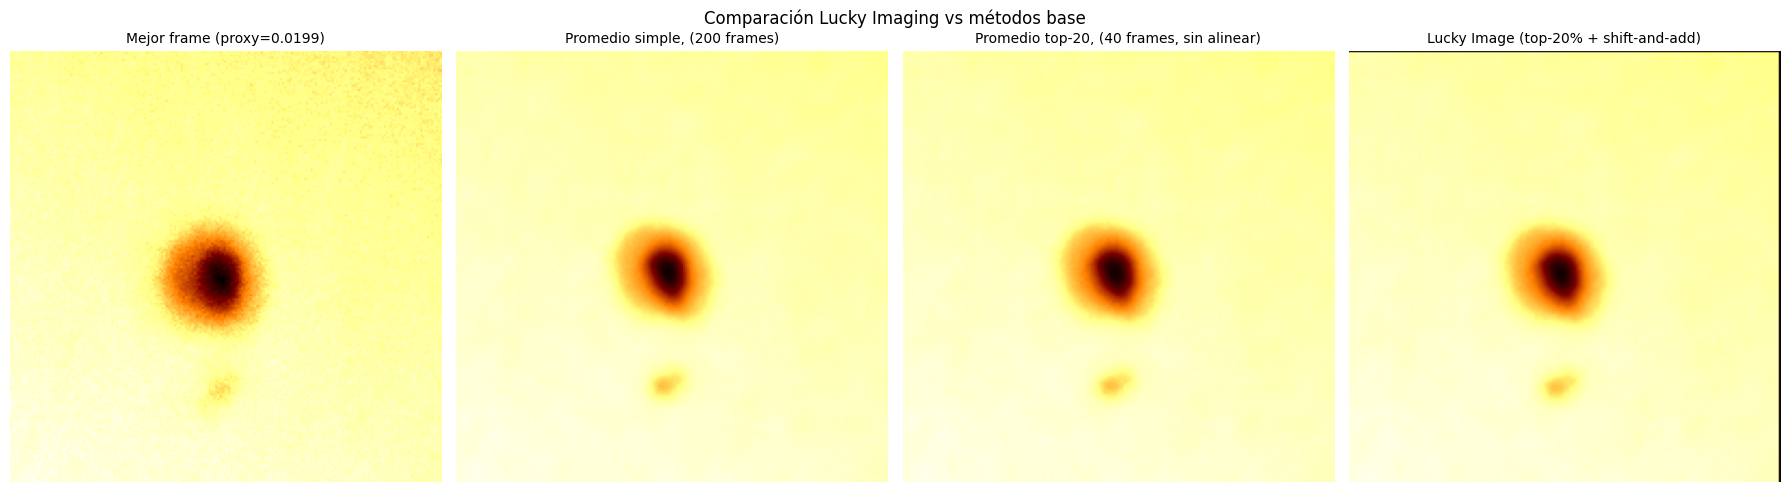

In [27]:
# Imágenes de comparación
best_frame    = frames[selected_indices[0]]
simple_mean   = frames.mean(axis=0)
topk_mean     = selected_frames.mean(axis=0)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
imgs   = [best_frame,  simple_mean,   topk_mean,         lucky_image]
titles = [f"Mejor frame (proxy={proxies[selected_indices[0]]:.4f})", f"Promedio simple, ({N} frames)", f"Promedio top-{K_PERCENT}, ({len(selected_indices)} frames, sin alinear)",
          f"Lucky Image (top-{K_PERCENT}% + shift-and-add)"]

for ax, img, title in zip(axes, imgs, titles):
    ax.imshow(img, cmap="afmhot", vmin=0, vmax=1)
    ax.set_title(title, fontsize=10)
    ax.axis("off")

plt.suptitle("Comparación Lucky Imaging vs métodos base", fontsize=12)
plt.tight_layout()
plt.show()

# 6. Métricas
Usamos el promedio simple como referencia (ground truth aproximado, ya que con muchos frames el promedio converge a la imagen real). Calculamos MSE, PSNR y SSIM para los cuatro métodos.

* MSE: Mean Squared Error (Error Cuadrático Medio)
Mide el error promedio píxel a píxel entre la imagen restaurada y la referencia. Se calcula como el promedio de (píxel_restaurado - píxel_referencia)². Rango: 0 a ∞. Menor es mejor.Un  MSE = 0 sería reconstrucción perfecta. Es sensible a errores grandes porque los eleva al cuadrado.

* PSNR:
* SSIM:


In [32]:
# librerias de las metricas que vamos a usar
from skimage.metrics import mean_squared_error as mse
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

In [31]:
reference = simple_mean  # reemplazar cuando tengan referencia común

m = mse(reference, lucky_image)
p = psnr(reference, lucky_image, data_range=1.0)
s = ssim(reference, lucky_image, data_range=1.0)

print("=== Métricas Lucky Image ===")
print(f"MSE:  {m:.5f}")
print(f"PSNR: {p:.2f} dB")
print(f"SSIM: {s:.4f}")

=== Métricas Lucky Image ===
MSE:  0.00649
PSNR: 21.88 dB
SSIM: 0.9650


Lucky Image preserva el 96.5% de la estructura de la imagen de referencia(por el SSIM).

Lucky Imaging no busca minimizar el error píxel a píxel (MSE/PSNR), sino preservar estructura, y el SSIM lo confirma.